# Fraud Detection - Baseline Model

Bu notebook'ta iki farklı yaklaşımı karşılaştırıyoruz: Tüm özellikleri kullanan Full Model (Baseline) ve sadece yorumlanabilir özellikler içeren Interpretable Model.

**Neden iki model?** Fraud detection'da sadece performans yeterli değil. Bir analist "bu işlem neden reddedildi?" diye sorduğunda net bir cevap verebilmek gerekiyor. V features gibi black-box özellikler yüksek AUC verse de müşteriye açıklaması zor. İşlem tutarı, kart bilgisi, adres uyumsuzluğu gibi özellikler ise herkesin anlayacağı sinyaller.

**Önemli:** Time-based split kullanıyoruz. Random split fraud detection'da data leakage'a yol açar çünkü model gelecekteki işlemleri görerek öğrenir. Gerçek dünyada böyle bir lüksümüz yok.

## 1. Veri Yükleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from lightgbm import LGBMClassifier
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# Load optimized data
import pickle

with open('../../data/train_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Shape: 590,540 x 434
Memory: 796.0 MB


## 2. Özellik Grupları

In [3]:
# Data types overview
print(df.dtypes.value_counts())

Int8        238
float64      80
Int16        75
category     12
category      4
int64         3
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Int32         1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64


In [4]:
# Define feature categories
categorical_cols = [col for col in df.columns if df[col].dtype in ['object', 'category']]
categorical_but_high_cardinality = [col for col in categorical_cols if df[col].nunique() > 50]

numeric_cols = [col for col in df.columns 
                if df[col].dtype in ['int64', 'float64', 'Int32', 'Int8', 'Int16']]
numeric_but_categorical = [col for col in numeric_cols 
                          if df[col].nunique() < 20 
                          and col not in ['isFraud', 'TransactionID']]

# Automated features (V, id_, D, M, C) - exclude D1
automated_prefixes = ['V', 'id_', 'D', 'M', 'C']
automated_features = [col for col in df.columns 
                     if any(col.startswith(p) for p in automated_prefixes)]

interpretable_from_automated = ['D1']  # D1 = days since last card transaction
automated_features = [col for col in automated_features if col not in interpretable_from_automated]

print(f"Categorical: {len(categorical_cols)} (high cardinality: {len(categorical_but_high_cardinality)})")
print(f"Numeric: {len(numeric_cols)} (categorical-like: {len(numeric_but_categorical)})")
print(f"Automated features: {len(automated_features)}")

Categorical: 37 (high cardinality: 12)
Numeric: 397 (categorical-like: 139)
Automated features: 416


In [5]:
# Separate target
df = df.set_index('TransactionID')
y = df['isFraud']
df = df.drop('isFraud', axis=1)

print(f"Fraud rate: {y.mean()*100:.2f}%")

Fraud rate: 3.50%


## 3. Encoding

In [6]:
# LightGBM Native Categorical Encoding Strategy
# LightGBM can use category dtype directly - no encoding needed!
# Only apply Frequency Encoding for high cardinality variables

# Split categoricals by cardinality
native_categorical = []        # LightGBM native categorical (< 50 unique)
high_card_categorical = []     # Frequency Encoding (> 50 unique)

for col in categorical_cols:
    n_unique = df[col].nunique()
    if n_unique <= 50:
        native_categorical.append(col)
    else:
        high_card_categorical.append(col)

print(f"Categorical variable distribution:")
print(f"  - LightGBM Native Categorical (≤ 50 unique): {len(native_categorical)}")
print(f"  - Frequency Encoding (> 50 unique): {len(high_card_categorical)} → {high_card_categorical}")

# 1. NATIVE CATEGORICAL - LightGBM will use directly
# Just ensure dtype is category
for col in native_categorical:
    if df[col].dtype.name != 'category':
        df[col] = df[col].astype('category')

# 2. FREQUENCY ENCODING - High cardinality categoricals
freq_maps = {}
for col in high_card_categorical:
    freq_map = df[col].value_counts().to_dict()
    df[f'{col}_freq'] = df[col].map(freq_map)
    df = df.drop(col, axis=1)
    freq_maps[col] = freq_map

# 3. NUMERIC BUT CATEGORICAL - Convert to category for LightGBM
for col in numeric_but_categorical:
    df[col] = df[col].astype('category')
    native_categorical.append(col)

# Save all categorical columns (to be used in model training)
categorical_features = [col for col in df.columns if df[col].dtype.name == 'category']

print(f"\nEncoding Summary:")
print(f"  - Native categorical (LightGBM): {len(categorical_features)} columns")
print(f"  - Frequency encoded: {len(freq_maps)} columns")
print(f"\nFinal shape: {df.shape}")
print(f"\nCategorical features for LightGBM: {categorical_features[:10]}..." if len(categorical_features) > 10 else f"\nCategorical features: {categorical_features}")

Categorical variable distribution:
  - LightGBM Native Categorical (≤ 50 unique): 25
  - Frequency Encoding (> 50 unique): 12 → ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']

Encoding Summary:
  - Native categorical (LightGBM): 164 columns
  - Frequency encoded: 12 columns

Final shape: (590540, 432)

Categorical features for LightGBM: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7']...

Encoding Summary:
  - Native categorical (LightGBM): 164 columns
  - Frequency encoded: 12 columns

Final shape: (590540, 432)

Categorical features for LightGBM: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7']...


## 4. Özellik Setleri

### Neden Native Categorical?

LightGBM, `category` tipindeki verileri direkt anlıyor ve en uygun bölünmeleri kendisi buluyor. One-Hot Encoding yapmıyoruz çünkü 5 kategorili bir değişken 4 yeni kolona dönüşüyor, bu da gereksiz şişkinlik. Label Encoding'de de sıralama anlamsız olabiliyor, Visa=1 ve Mastercard=2 demek mantıklı bir şey ifade etmiyor.

Yüksek kardinaliteli değişkenler için Frequency Encoding kullanıyoruz. P_emaildomain, R_emaildomain, DeviceInfo gibi 50'den fazla kategoriye sahip değişkenlerde LightGBM yavaşlayabiliyor. Ayrıca frekans bilgisi kendi başına bir fraud sinyali, nadir görülen değerler genellikle riskli.

In [7]:
# Create feature sets
time_col = 'TransactionDT'

# Full features (baseline - orijinal data)
X_full = df.drop([time_col], axis=1)

# Interpretable features (remove V, id_, M, C, D2-D15, keep D1)
automated_prefixes_for_removal = ['V', 'id_', 'M', 'C']
d_cols_to_remove = [col for col in df.columns if col.startswith('D') and col != 'D1']

cols_to_remove = [col for col in df.columns 
                  if any(col.startswith(p) for p in automated_prefixes_for_removal)]
cols_to_remove.extend(d_cols_to_remove)
cols_to_remove = list(set(cols_to_remove))

X_interpretable = df.drop([col for col in cols_to_remove if col in df.columns] + [time_col], axis=1)

# Categorical features for each model (LightGBM native support)
cat_features_full = [col for col in X_full.columns if X_full[col].dtype.name == 'category']
cat_features_interp = [col for col in X_interpretable.columns if X_interpretable[col].dtype.name == 'category']

print(f"Full features (Baseline): {X_full.shape[1]} (categorical: {len(cat_features_full)})")
print(f"Interpretable features: {X_interpretable.shape[1]} (categorical: {len(cat_features_interp)})")
print(f"\nInterpretable columns: {list(X_interpretable.columns)}")

Full features (Baseline): 431 (categorical: 164)
Interpretable features: 15 (categorical: 3)

Interpretable columns: ['TransactionAmt', 'ProductCD', 'card4', 'card6', 'dist1', 'dist2', 'D1', 'card1_freq', 'card2_freq', 'card3_freq', 'card5_freq', 'addr1_freq', 'addr2_freq', 'P_emaildomain_freq', 'R_emaildomain_freq']


### Time-Based Split Neden Önemli?

Random split yaparsak validation setinde Ocak ayından bir işlem, train setinde Mart ayından bir işlem olabilir. Model "geleceği görerek" öğreniyor, bu da gerçekçi olmayan yüksek AUC'ye yol açıyor. Production'da bu performansı asla göremeyiz.

Time-based split ile veriyi 3 parçaya ayırıyoruz: %60 Train, %20 Validation, %20 Test. Model sadece geçmişi görerek geleceği tahmin etmeyi öğreniyor.

In [8]:
# TIME-BASED SPLIT 

sort_idx = df[time_col].argsort()
df_sorted = df.iloc[sort_idx]
y_sorted = y.iloc[sort_idx]

# %60 Train, %20 Validation, %20 Test
n_total = len(df_sorted)
n_train = int(n_total * 0.60)
n_val = int(n_total * 0.20)
n_test = n_total - n_train - n_val

# Full features
X_full_sorted = X_full.iloc[sort_idx]
X_full_train = X_full_sorted.iloc[:n_train]
X_full_val = X_full_sorted.iloc[n_train:n_train+n_val]
X_full_test = X_full_sorted.iloc[n_train+n_val:]

# Interpretable features
X_interp_sorted = X_interpretable.iloc[sort_idx]
X_interp_train = X_interp_sorted.iloc[:n_train]
X_interp_val = X_interp_sorted.iloc[n_train:n_train+n_val]
X_interp_test = X_interp_sorted.iloc[n_train+n_val:]

# Target
y_train = y_sorted.iloc[:n_train]
y_val = y_sorted.iloc[n_train:n_train+n_val]
y_test = y_sorted.iloc[n_train+n_val:]

# Zaman aralıklarını kontrol et
train_time = df_sorted[time_col].iloc[:n_train]
val_time = df_sorted[time_col].iloc[n_train:n_train+n_val]
test_time = df_sorted[time_col].iloc[n_train+n_val:]

print(f"TIME-BASED SPLIT")
print(f"{'Set':<8} {'Count':>10} {'%':>6} {'Time Range':>25} {'Fraud Rate':>12}")
print("-" * 65)
print(f"{'Train':<8} {len(y_train):>10,} {len(y_train)/n_total*100:>5.1f}% {train_time.min():>10,} - {train_time.max():<10,} {y_train.mean()*100:>10.2f}%")
print(f"{'Val':<8} {len(y_val):>10,} {len(y_val)/n_total*100:>5.1f}% {val_time.min():>10,} - {val_time.max():<10,} {y_val.mean()*100:>10.2f}%")
print(f"{'Test':<8} {len(y_test):>10,} {len(y_test)/n_total*100:>5.1f}% {test_time.min():>10,} - {test_time.max():<10,} {y_test.mean()*100:>10.2f}%")
print(f"\nTrain → Val gap: {val_time.min() - train_time.max():,} seconds")
print(f"Val → Test gap: {test_time.min() - val_time.max():,} seconds")

TIME-BASED SPLIT
Set           Count      %                Time Range   Fraud Rate
-----------------------------------------------------------------
Train       354,324  60.0%     86,400 - 8,745,772        3.38%
Val         118,108  20.0%  8,745,798 - 12,192,842       3.90%
Test        118,108  20.0% 12,192,900 - 15,811,131       3.44%

Train → Val gap: 26 seconds
Val → Test gap: 58 seconds


## 5. Model Eğitimi

In [9]:
# Model 1: Full Features (with native categorical support)
model_full = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=25, random_state=42, class_weight='balanced', verbose=-1
)
model_full.fit(
    X_full_train, y_train, 
    eval_set=[(X_full_val, y_val)], 
    categorical_feature=cat_features_full
)
print(f"Model 1 (Full) trained - {len(cat_features_full)} categorical features used natively")

Model 1 (Full) trained - 164 categorical features used natively


In [10]:
# Model 2: Interpretable Features (with native categorical support)
model_interp = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=25, random_state=42, class_weight='balanced', verbose=-1
)
model_interp.fit(
    X_interp_train, y_train, 
    eval_set=[(X_interp_val, y_val)], 
    categorical_feature=cat_features_interp
)
print(f"Model 2 (Interpretable) trained - {len(cat_features_interp)} categorical features used natively")

Model 2 (Interpretable) trained - 3 categorical features used natively


## 6. Model Karşılaştırması

Full model AUC 0.94, Interpretable model 0.90 civarında. 793 özellik çıkardık ama sadece yüzde 4 kayıp var. Bu aslında iyi haber çünkü 800 özelliği takip etmek yerine 16 özelliğe odaklanabiliriz. Veri yapısı değiştiğinde veya yeni bir özellik eklendiğinde bakım maliyeti dramatik şekilde düşüyor.

In [11]:
# Predictions
y_full_val_proba = model_full.predict_proba(X_full_val)[:, 1]
y_full_val_pred = model_full.predict(X_full_val)

y_interp_val_proba = model_interp.predict_proba(X_interp_val)[:, 1]
y_interp_val_pred = model_interp.predict(X_interp_val)

# Metrics
metrics_full = {
    'val_auc': roc_auc_score(y_val, y_full_val_proba),
    'precision': precision_score(y_val, y_full_val_pred),
    'recall': recall_score(y_val, y_full_val_pred),
    'f1': f1_score(y_val, y_full_val_pred)
}

metrics_interp = {
    'val_auc': roc_auc_score(y_val, y_interp_val_proba),
    'precision': precision_score(y_val, y_interp_val_pred),
    'recall': recall_score(y_val, y_interp_val_pred),
    'f1': f1_score(y_val, y_interp_val_pred)
}

# Results table
print(f"{'Metric':<15} {'Full':>12} {'Interpretable':>15} {'Diff':>10}")
print("-" * 52)
for metric in ['val_auc', 'precision', 'recall', 'f1']:
    diff = metrics_full[metric] - metrics_interp[metric]
    print(f"{metric:<15} {metrics_full[metric]:>12.4f} {metrics_interp[metric]:>15.4f} {diff:>+10.4f}")
print(f"\nFeatures: Full={X_full.shape[1]} | Interpretable={X_interpretable.shape[1]}")

Metric                  Full   Interpretable       Diff
----------------------------------------------------
val_auc               0.9187          0.8453    +0.0734
precision             0.2814          0.1538    +0.1276
recall                0.7237          0.6647    +0.0590
f1                    0.4052          0.2498    +0.1554

Features: Full=431 | Interpretable=15


## 7. ROC ve Metrikler

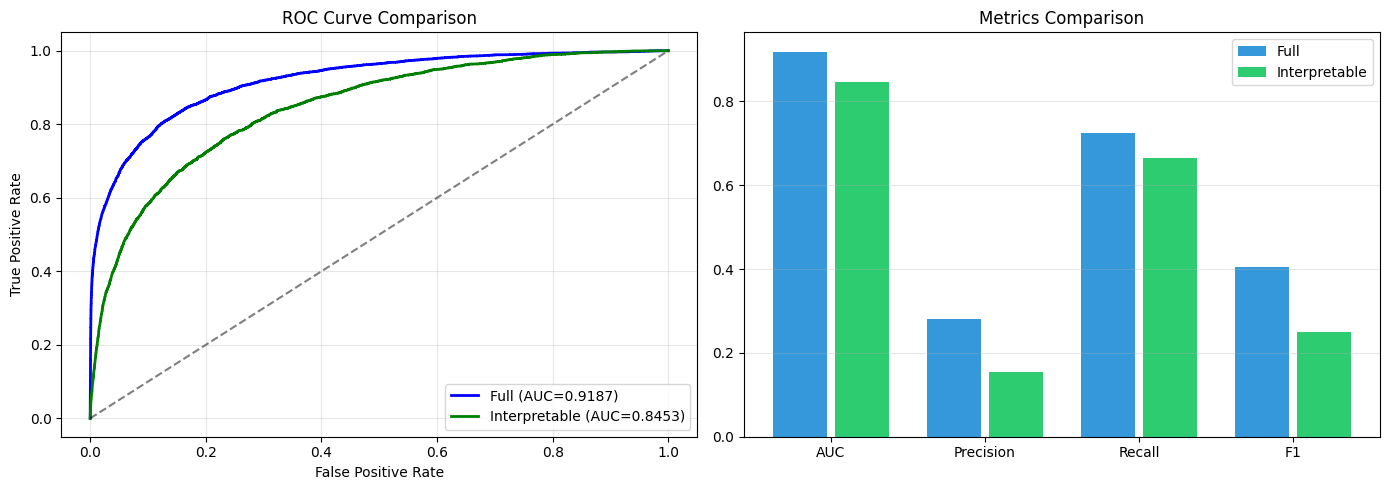

In [12]:
# ROC Curves
fpr_full, tpr_full, _ = roc_curve(y_val, y_full_val_proba)
fpr_interp, tpr_interp, _ = roc_curve(y_val, y_interp_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1 = axes[0]
ax1.plot(fpr_full, tpr_full, 'b-', lw=2, label=f'Full (AUC={metrics_full["val_auc"]:.4f})')
ax1.plot(fpr_interp, tpr_interp, 'g-', lw=2, label=f'Interpretable (AUC={metrics_interp["val_auc"]:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Metrics bar chart
ax2 = axes[1]
metrics_names = ['AUC', 'Precision', 'Recall', 'F1']
full_vals = [metrics_full['val_auc'], metrics_full['precision'], metrics_full['recall'], metrics_full['f1']]
interp_vals = [metrics_interp['val_auc'], metrics_interp['precision'], metrics_interp['recall'], metrics_interp['f1']]

x = np.arange(len(metrics_names))
ax2.bar(x - 0.2, full_vals, 0.35, label='Full', color='#3498db')
ax2.bar(x + 0.2, interp_vals, 0.35, label='Interpretable', color='#2ecc71')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.set_title('Metrics Comparison')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Confusion Matrix

Fraud detection'da hataların maliyeti eşit değil. Kaçan fraud doğrudan para kaybı ve güven erozyonu demek. Yanlış alarm ise operasyonel maliyet ve kötü müşteri deneyimi. Bu iki hatanın dengesini iş ihtiyacına göre ayarlamak gerekiyor.

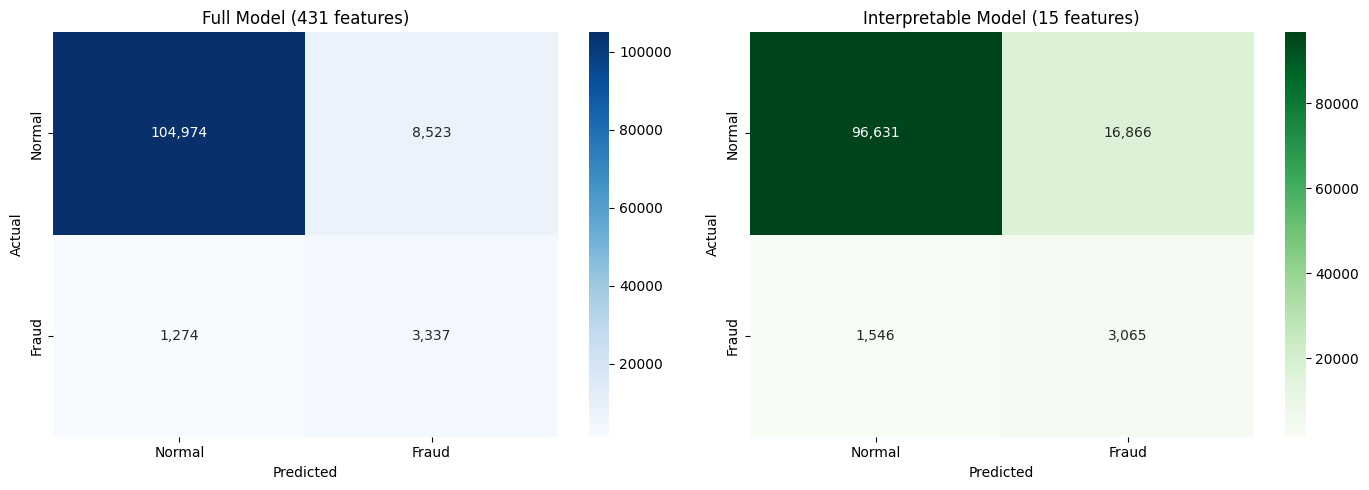


Metric                            Full   Interpretable       Diff
--------------------------------------------------------------
Fraud Caught (TP)                3,337           3,065       +272
Fraud Missed (FN)                1,274           1,546       -272
False Alarms (FP)                8,523          16,866     -8,343


In [13]:
# Confusion matrices
cm_full = confusion_matrix(y_val, y_full_val_pred)
cm_interp = confusion_matrix(y_val, y_interp_val_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full model
sns.heatmap(cm_full, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[0].set_title(f'Full Model ({X_full.shape[1]} features)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Interpretable model
sns.heatmap(cm_interp, annot=True, fmt=',d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[1].set_title(f'Interpretable Model ({X_interpretable.shape[1]} features)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Key metrics summary
tn_f, fp_f, fn_f, tp_f = cm_full.ravel()
tn_i, fp_i, fn_i, tp_i = cm_interp.ravel()

print(f"\n{'Metric':<25} {'Full':>12} {'Interpretable':>15} {'Diff':>10}")
print("-" * 62)
print(f"{'Fraud Caught (TP)':<25} {tp_f:>12,} {tp_i:>15,} {tp_f-tp_i:>+10,}")
print(f"{'Fraud Missed (FN)':<25} {fn_f:>12,} {fn_i:>15,} {fn_f-fn_i:>+10,}")
print(f"{'False Alarms (FP)':<25} {fp_f:>12,} {fp_i:>15,} {fp_f-fp_i:>+10,}")

## 9. Feature Importance

Full model'de V features baskın ama bunlar black-box. Ne anlama geldiklerini bilmiyoruz, açıklayamıyoruz. Interpretable model'de ise TransactionAmt açık ara birinci. Kart özellikleri, adres bilgileri, D1 gibi değişkenler de önemli ve hepsini bir analist rahatlıkla yorumlayabilir.

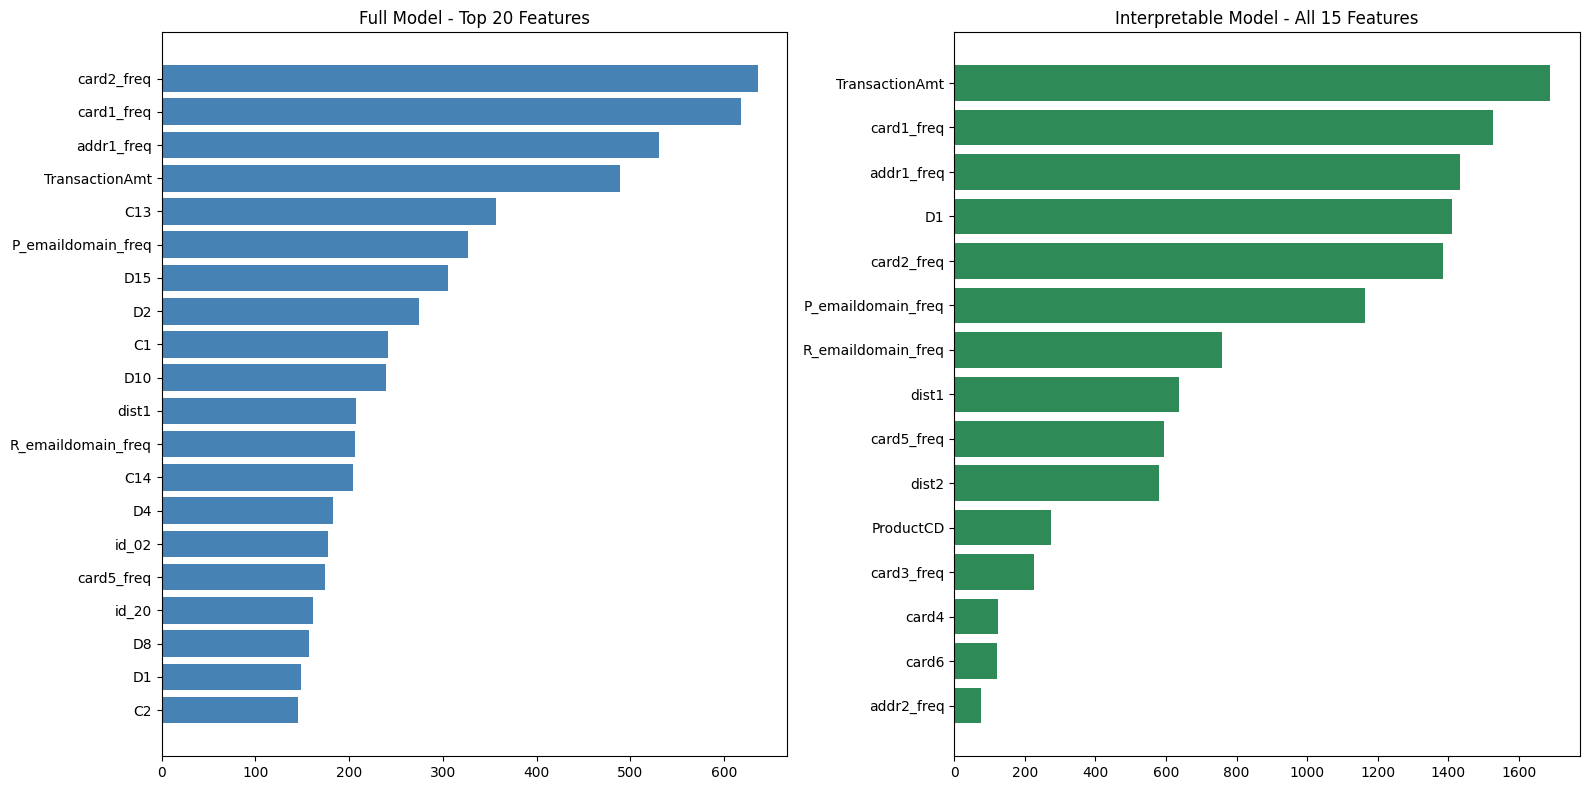

In [14]:
# Feature importance
fi_full = pd.DataFrame({
    'feature': X_full.columns,
    'importance': model_full.feature_importances_
}).sort_values('importance', ascending=False)

fi_interp = pd.DataFrame({
    'feature': X_interpretable.columns,
    'importance': model_interp.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Full model top 20
top20 = fi_full.head(20)
axes[0].barh(range(20), top20['importance'], color='steelblue')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20['feature'])
axes[0].invert_yaxis()
axes[0].set_title(f'Full Model - Top 20 Features')

# Interpretable model all features
axes[1].barh(range(len(fi_interp)), fi_interp['importance'], color='seagreen')
axes[1].set_yticks(range(len(fi_interp)))
axes[1].set_yticklabels(fi_interp['feature'])
axes[1].invert_yaxis()
axes[1].set_title(f'Interpretable Model - All {len(fi_interp)} Features')

plt.tight_layout()
plt.show()

## 10. Model Kaydetme

Real-time otomatik blokaj için Full model mantıklı çünkü milisaniye kararlar gerekiyor ve her yüzde önemli. Manuel review kuyruğu için Interpretable model daha uygun çünkü analist ekranında "işlem tutarı yüksek, yeni kart, adres uyumsuz" gibi açıklamalar gösterilebilir. Regulatory audit'lerde de Interpretable model şart, "algoritma öyle dedi" cevabı yeterli değil.

In [15]:
# Save models
os.makedirs('../../models', exist_ok=True)

joblib.dump({
    'model': model_full,
    'features': X_full.columns.tolist(),
    'metrics': metrics_full
}, '../../models/model_full_features.pkl')

joblib.dump({
    'model': model_interp,
    'features': X_interpretable.columns.tolist(),
    'metrics': metrics_interp
}, '../../models/model_interpretable.pkl')

print("Models saved:")
print(f"  - model_full_features.pkl ({X_full.shape[1]} features, AUC={metrics_full['val_auc']:.4f})")
print(f"  - model_interpretable.pkl ({X_interpretable.shape[1]} features, AUC={metrics_interp['val_auc']:.4f})")

Models saved:
  - model_full_features.pkl (431 features, AUC=0.9187)
  - model_interpretable.pkl (15 features, AUC=0.8453)


## 11. Undersampling Denemeleri

Her 100 işlemin sadece 3-4 tanesi fraud. Bu dengesizlik, modelin sadece "fraud değil" diyerek yüzde 96 başarı göstermesine yol açar ki bu tamamen yanıltıcı. Şimdiye kadar `class_weight='balanced'` kullandık, şimdi undersampling ile karşılaştırıyoruz.

1:1 oranı çok agresif, normal işlemlerin yüzde 97'si atılıyor ve model çeşitliliği kaybediyor. 1:10+ ise class_weight ile çok fark yaratmıyor. 1:5 iyi bir denge noktası, fraud oranı yüzde 3.5'ten yüzde 16.7'ye çıkıyor ve yeterli normal örnek korunuyor.

In [16]:
# Undersampling function
def undersample_data(X, y, ratio=1.0, random_state=42):
    """
    Undersample the majority class.
    ratio: minority/majority ratio (1.0 = equal counts)
    """
    np.random.seed(random_state)
    
    # Separate classes
    fraud_idx = y[y == 1].index
    normal_idx = y[y == 0].index
    
    n_fraud = len(fraud_idx)
    n_normal_target = int(n_fraud / ratio) if ratio > 0 else len(normal_idx)
    
    # Randomly select from normal transactions
    normal_idx_sampled = np.random.choice(normal_idx, size=min(n_normal_target, len(normal_idx)), replace=False)
    
    # Combine
    selected_idx = np.concatenate([fraud_idx, normal_idx_sampled])
    
    X_resampled = X.loc[selected_idx]
    y_resampled = y.loc[selected_idx]
    
    return X_resampled, y_resampled

# Try different undersampling ratios
ratios = {
    '1:1': 1.0,    # Equal fraud and normal
    '1:2': 0.5,    # 1 fraud, 2 normal
    '1:5': 0.2,    # 1 fraud, 5 normal
}

print(f"Original data - Fraud: {y_train.sum():,} | Normal: {(y_train == 0).sum():,} | Ratio: 1:{(y_train == 0).sum() // y_train.sum()}")
print("\nAfter undersampling:")
for name, ratio in ratios.items():
    X_us, y_us = undersample_data(X_full_train, y_train, ratio=ratio)
    print(f"  {name} → Fraud: {y_us.sum():,} | Normal: {(y_us == 0).sum():,} | Total: {len(y_us):,}")

Original data - Fraud: 11,988 | Normal: 342,336 | Ratio: 1:28

After undersampling:
  1:1 → Fraud: 11,988 | Normal: 11,988 | Total: 23,976
  1:2 → Fraud: 11,988 | Normal: 23,976 | Total: 35,964
  1:5 → Fraud: 11,988 | Normal: 59,940 | Total: 71,928
  1:2 → Fraud: 11,988 | Normal: 23,976 | Total: 35,964
  1:5 → Fraud: 11,988 | Normal: 59,940 | Total: 71,928


In [17]:
# 1:5 Undersampling Model Training (Balanced approach)
# Why 1:5? 
# - 1:1 too aggressive → high information loss
# - 1:10+ → similar to class_weight
# - 1:5 → good balance, enough normal samples retained

UNDERSAMPLE_RATIO = 0.2  # 1 fraud : 5 normal

X_full_train_us, y_train_us = undersample_data(X_full_train, y_train, ratio=UNDERSAMPLE_RATIO)
X_interp_train_us, _ = undersample_data(X_interp_train, y_train, ratio=UNDERSAMPLE_RATIO)

print(f"Undersampled Training Set (1:5):")
print(f"  Full: {X_full_train_us.shape[0]:,} samples (original: {X_full_train.shape[0]:,})")
print(f"  Interpretable: {X_interp_train_us.shape[0]:,} samples")
print(f"  Fraud rate: {y_train_us.mean()*100:.1f}% (original: {y_train.mean()*100:.1f}%)")
print(f"  Data reduction: {100 - (len(y_train_us) / len(y_train) * 100):.1f}%")

# Full Model - Undersampled
model_full_us = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=25, random_state=42, verbose=-1
    # No class_weight - data is already more balanced
)
model_full_us.fit(
    X_full_train_us, y_train_us,
    eval_set=[(X_full_val, y_val)],
    categorical_feature=cat_features_full
)

# Interpretable Model - Undersampled
model_interp_us = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=25, random_state=42, verbose=-1
)
model_interp_us.fit(
    X_interp_train_us, y_train_us,
    eval_set=[(X_interp_val, y_val)],
    categorical_feature=cat_features_interp
)

print("\nUndersampled models (1:5) trained!")

Undersampled Training Set (1:5):
  Full: 71,928 samples (original: 354,324)
  Interpretable: 71,928 samples
  Fraud rate: 16.7% (original: 3.4%)
  Data reduction: 79.7%

Undersampled models (1:5) trained!

Undersampled models (1:5) trained!


In [18]:
# Undersampled Model Comparison
y_full_us_proba = model_full_us.predict_proba(X_full_val)[:, 1]
y_full_us_pred = model_full_us.predict(X_full_val)

y_interp_us_proba = model_interp_us.predict_proba(X_interp_val)[:, 1]
y_interp_us_pred = model_interp_us.predict(X_interp_val)

# Metrics
metrics_full_us = {
    'val_auc': roc_auc_score(y_val, y_full_us_proba),
    'precision': precision_score(y_val, y_full_us_pred),
    'recall': recall_score(y_val, y_full_us_pred),
    'f1': f1_score(y_val, y_full_us_pred)
}

metrics_interp_us = {
    'val_auc': roc_auc_score(y_val, y_interp_us_proba),
    'precision': precision_score(y_val, y_interp_us_pred),
    'recall': recall_score(y_val, y_interp_us_pred),
    'f1': f1_score(y_val, y_interp_us_pred)
}

# Comparison table
print("UNDERSAMPLING vs CLASS_WEIGHT COMPARISON")

print(f"\n{'Model':<25} {'AUC':>10} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-" * 67)
print(f"{'Full (class_weight)':<25} {metrics_full['val_auc']:>10.4f} {metrics_full['precision']:>12.4f} {metrics_full['recall']:>10.4f} {metrics_full['f1']:>10.4f}")
print(f"{'Full (undersampled)':<25} {metrics_full_us['val_auc']:>10.4f} {metrics_full_us['precision']:>12.4f} {metrics_full_us['recall']:>10.4f} {metrics_full_us['f1']:>10.4f}")
print(f"{'Diff':<25} {metrics_full_us['val_auc']-metrics_full['val_auc']:>+10.4f} {metrics_full_us['precision']-metrics_full['precision']:>+12.4f} {metrics_full_us['recall']-metrics_full['recall']:>+10.4f} {metrics_full_us['f1']-metrics_full['f1']:>+10.4f}")
print("-" * 67)
print(f"{'Interp (class_weight)':<25} {metrics_interp['val_auc']:>10.4f} {metrics_interp['precision']:>12.4f} {metrics_interp['recall']:>10.4f} {metrics_interp['f1']:>10.4f}")
print(f"{'Interp (undersampled)':<25} {metrics_interp_us['val_auc']:>10.4f} {metrics_interp_us['precision']:>12.4f} {metrics_interp_us['recall']:>10.4f} {metrics_interp_us['f1']:>10.4f}")
print(f"{'Diff':<25} {metrics_interp_us['val_auc']-metrics_interp['val_auc']:>+10.4f} {metrics_interp_us['precision']-metrics_interp['precision']:>+12.4f} {metrics_interp_us['recall']-metrics_interp['recall']:>+10.4f} {metrics_interp_us['f1']-metrics_interp['f1']:>+10.4f}")

UNDERSAMPLING vs CLASS_WEIGHT COMPARISON

Model                            AUC    Precision     Recall         F1
-------------------------------------------------------------------
Full (class_weight)           0.9187       0.2814     0.7237     0.4052
Full (undersampled)           0.9210       0.6237     0.5266     0.5710
Diff                         +0.0023      +0.3423    -0.1971    +0.1658
-------------------------------------------------------------------
Interp (class_weight)         0.8453       0.1538     0.6647     0.2498
Interp (undersampled)         0.8479       0.3557     0.3479     0.3518
Diff                         +0.0026      +0.2020    -0.3169    +0.1020


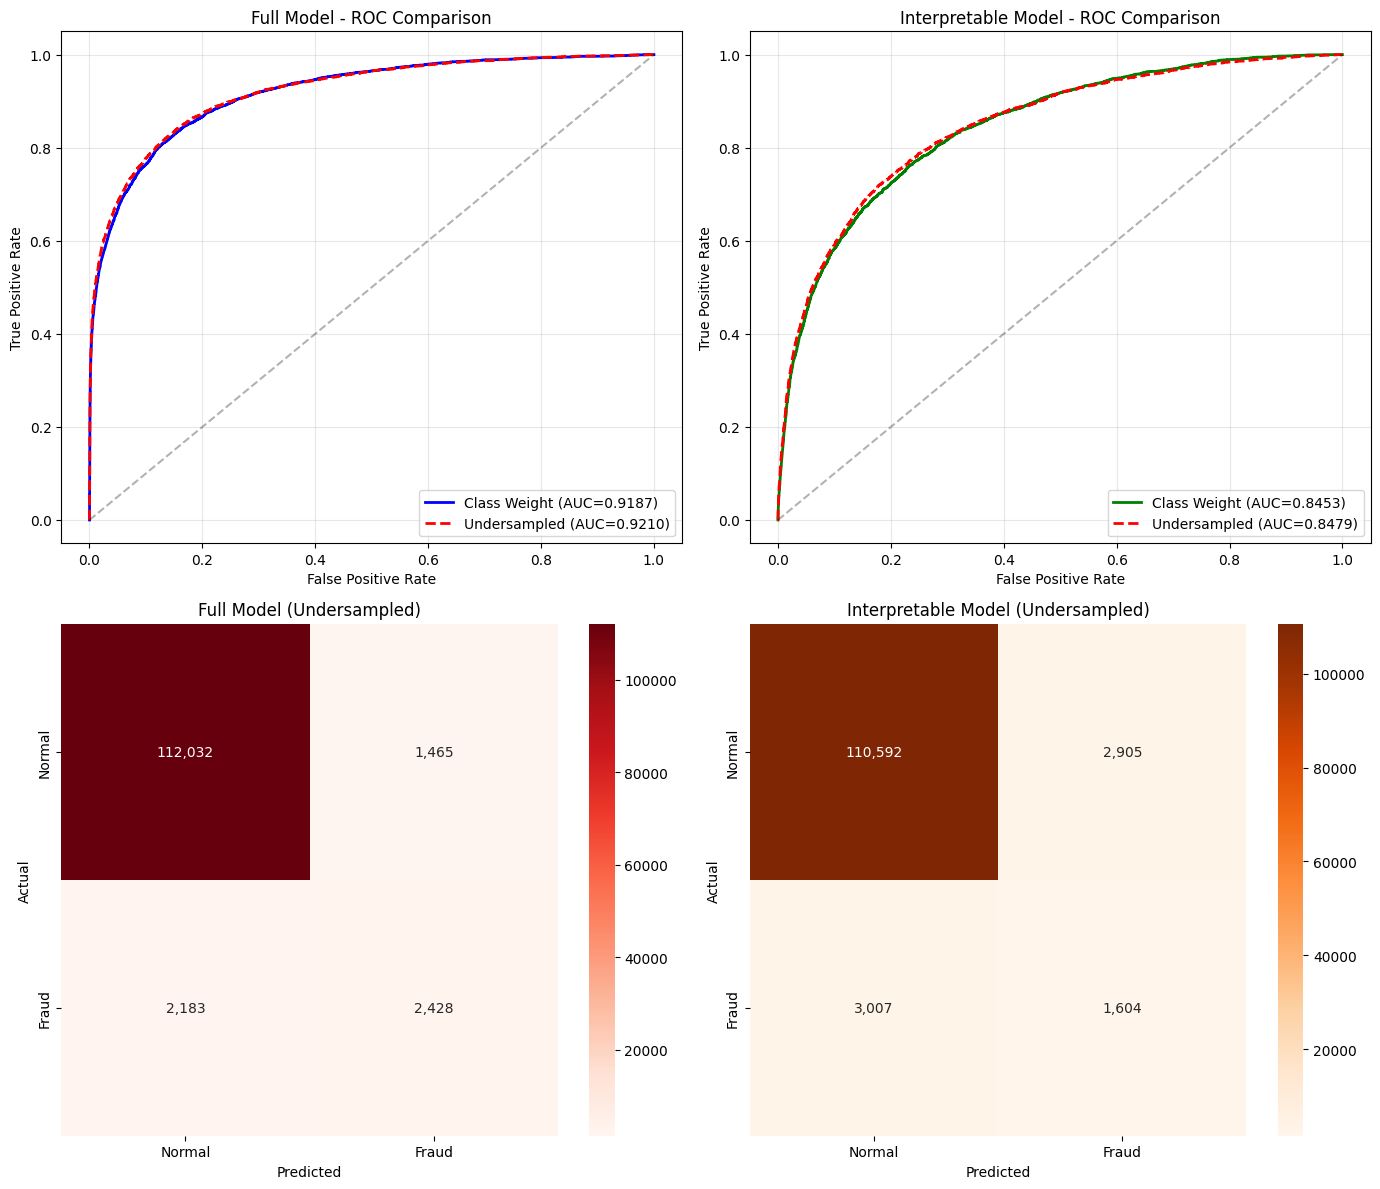


CONFUSION MATRIX COMPARISON (Undersampled)

Metric                       Full (CW)    Full (US)  Interp (CW)  Interp (US)
---------------------------------------------------------------------------
Fraud Caught (TP)                3,337        2,428        3,065        1,604
Fraud Missed (FN)                1,274        2,183        1,546        3,007
False Alarms (FP)                8,523        1,465       16,866        2,905


In [19]:
# Visual Comparison - ROC and Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curves - Full Model
ax1 = axes[0, 0]
fpr_full_us, tpr_full_us, _ = roc_curve(y_val, y_full_us_proba)
ax1.plot(fpr_full, tpr_full, 'b-', lw=2, label=f'Class Weight (AUC={metrics_full["val_auc"]:.4f})')
ax1.plot(fpr_full_us, tpr_full_us, 'r--', lw=2, label=f'Undersampled (AUC={metrics_full_us["val_auc"]:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Full Model - ROC Comparison')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# 2. ROC Curves - Interpretable Model
ax2 = axes[0, 1]
fpr_interp_us, tpr_interp_us, _ = roc_curve(y_val, y_interp_us_proba)
ax2.plot(fpr_interp, tpr_interp, 'g-', lw=2, label=f'Class Weight (AUC={metrics_interp["val_auc"]:.4f})')
ax2.plot(fpr_interp_us, tpr_interp_us, 'r--', lw=2, label=f'Undersampled (AUC={metrics_interp_us["val_auc"]:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Interpretable Model - ROC Comparison')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

# 3. Confusion Matrix - Full Undersampled
ax3 = axes[1, 0]
cm_full_us = confusion_matrix(y_val, y_full_us_pred)
sns.heatmap(cm_full_us, annot=True, fmt=',d', cmap='Reds', ax=ax3,
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
ax3.set_title('Full Model (Undersampled)')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# 4. Confusion Matrix - Interpretable Undersampled
ax4 = axes[1, 1]
cm_interp_us = confusion_matrix(y_val, y_interp_us_pred)
sns.heatmap(cm_interp_us, annot=True, fmt=',d', cmap='Oranges', ax=ax4,
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
ax4.set_title('Interpretable Model (Undersampled)')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Confusion Matrix Comparison
tn_f_us, fp_f_us, fn_f_us, tp_f_us = cm_full_us.ravel()
tn_i_us, fp_i_us, fn_i_us, tp_i_us = cm_interp_us.ravel()

print("\nCONFUSION MATRIX COMPARISON (Undersampled)")
print(f"\n{'Metric':<25} {'Full (CW)':>12} {'Full (US)':>12} {'Interp (CW)':>12} {'Interp (US)':>12}")
print("-" * 75)
print(f"{'Fraud Caught (TP)':<25} {tp_f:>12,} {tp_f_us:>12,} {tp_i:>12,} {tp_i_us:>12,}")
print(f"{'Fraud Missed (FN)':<25} {fn_f:>12,} {fn_f_us:>12,} {fn_i:>12,} {fn_i_us:>12,}")
print(f"{'False Alarms (FP)':<25} {fp_f:>12,} {fp_f_us:>12,} {fp_i:>12,} {fp_i_us:>12,}")

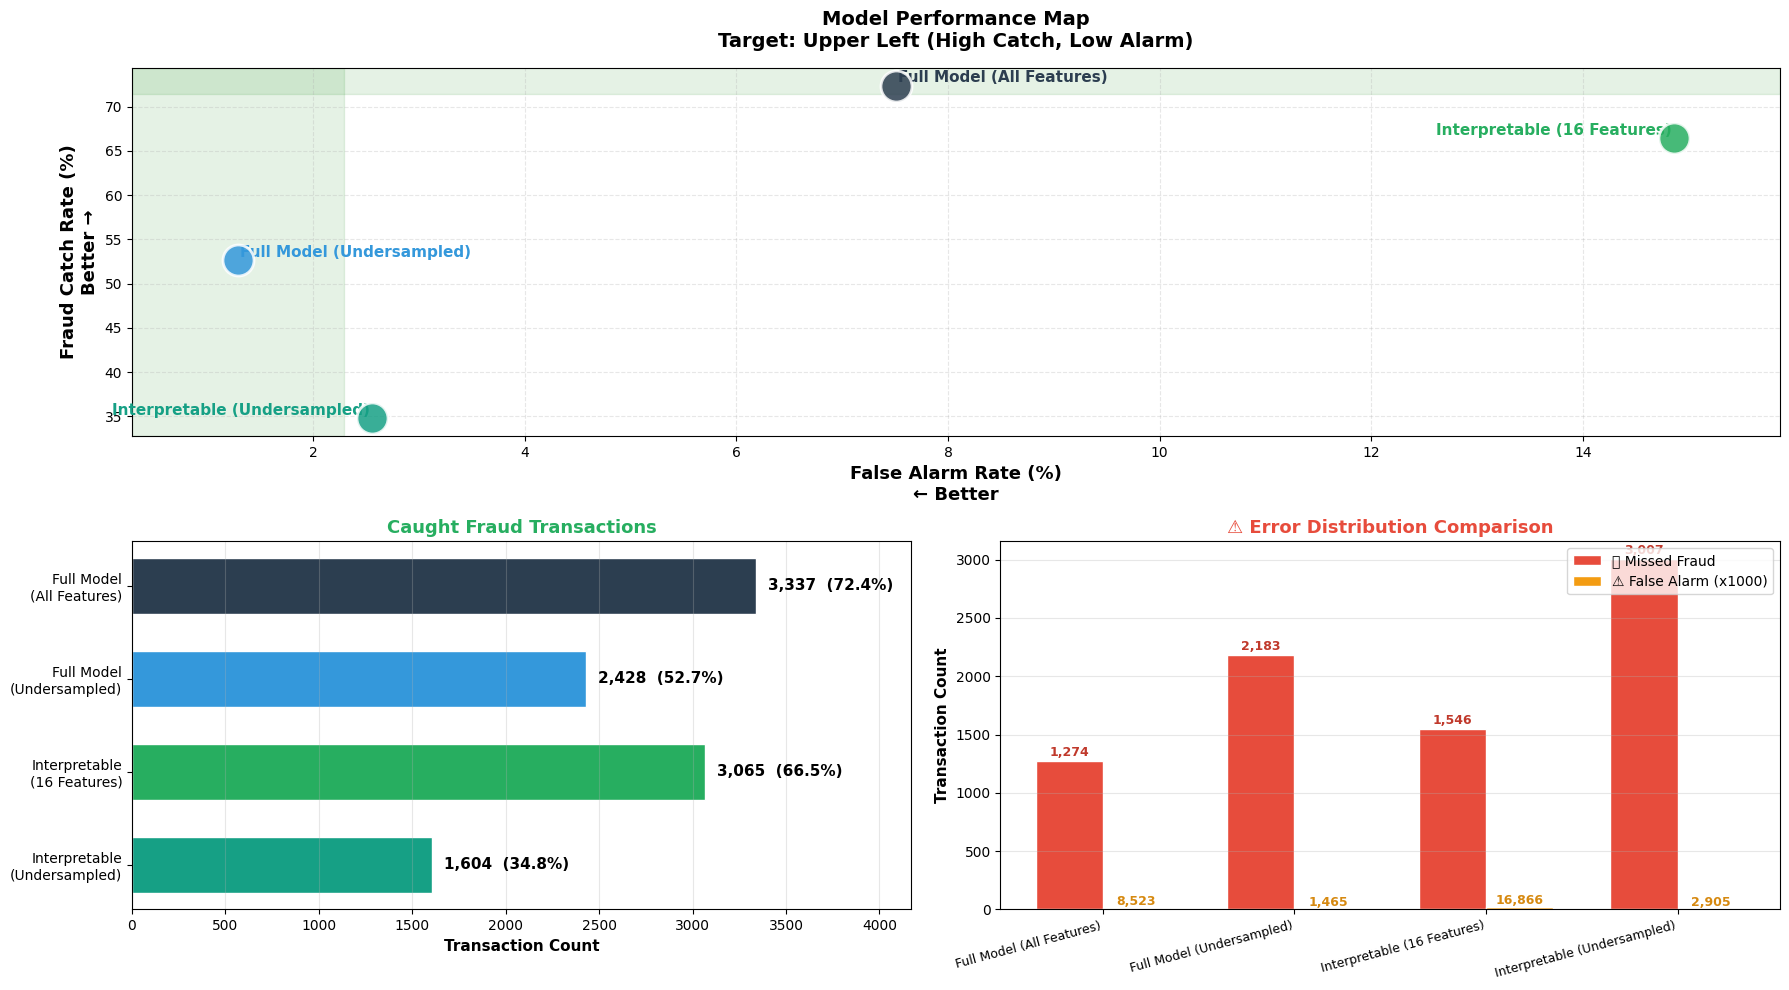


Model                                Caught       Missed     False Alarm 
----------------------------------------------------------------------------------------------------
Full (class_weight)               3,337 (72.4%)    1,274        8,523
Full (undersampled)               2,428 (52.7%)    2,183        1,465
Interpretable (class_weight)      3,065 (66.5%)    1,546       16,866
Interpretable (undersampled)      1,604 (34.8%)    3,007        2,905


In [20]:
# Executive Summary - Model Performance Comparison
# Model data
models = ['Full Model\n(All Features)', 'Full Model\n(Undersampled)', 
          'Interpretable\n(16 Features)', 'Interpretable\n(Undersampled)']
tp_values = [tp_f, tp_f_us, tp_i, tp_i_us]
fn_values = [fn_f, fn_f_us, fn_i, fn_i_us]
fp_values = [fp_f, fp_f_us, fp_i, fp_i_us]

# Calculate fraud catch rate and false alarm rate
total_fraud = tp_values[0] + fn_values[0]  # Total actual fraud
total_normal = fp_values[0] + tn_f  # Total actual normal
catch_rates = [tp / total_fraud * 100 for tp in tp_values]
false_alarm_rates = [fp / total_normal * 100 for fp in fp_values]

colors_main = ['#2C3E50', '#3498DB', '#27AE60', '#16A085']

fig = plt.figure(figsize=(18, 10))

ax_main = fig.add_subplot(2, 2, (1, 2))

for i, (model, catch, false_alarm, color) in enumerate(zip(models, catch_rates, false_alarm_rates, colors_main)):
    ax_main.scatter(false_alarm, catch, s=500, c=color, alpha=0.85, edgecolors='white', linewidths=2, zorder=5)
    # Write model name next to point
    offset_x = 0.15 if i < 2 else -0.15
    ha = 'left' if i < 2 else 'right'
    ax_main.annotate(model.replace('\n', ' '), 
                     (false_alarm, catch),
                     xytext=(offset_x, 0.5), textcoords='offset fontsize',
                     fontsize=11, fontweight='bold', color=color, ha=ha, va='center')

ax_main.set_xlabel('False Alarm Rate (%)\n← Better', fontsize=13, fontweight='bold')
ax_main.set_ylabel('Fraud Catch Rate (%)\nBetter →', fontsize=13, fontweight='bold')
ax_main.set_title('Model Performance Map\nTarget: Upper Left (High Catch, Low Alarm)', 
                  fontsize=14, fontweight='bold', pad=15)
ax_main.grid(True, alpha=0.3, linestyle='--')
ax_main.set_xlim(min(false_alarm_rates) - 1, max(false_alarm_rates) + 1)
ax_main.set_ylim(min(catch_rates) - 2, max(catch_rates) + 2)

# Mark ideal zone
ax_main.axhspan(max(catch_rates) - 1, max(catch_rates) + 3, alpha=0.1, color='green', zorder=1)
ax_main.axvspan(min(false_alarm_rates) - 1, min(false_alarm_rates) + 1, alpha=0.1, color='green', zorder=1)

# Bottom left: Caught Fraud Count
ax_left = fig.add_subplot(2, 2, 3)
bars_left = ax_left.barh(models, tp_values, color=colors_main, edgecolor='white', height=0.6)
ax_left.set_xlabel('Transaction Count', fontsize=11, fontweight='bold')
ax_left.set_title('Caught Fraud Transactions', fontsize=13, fontweight='bold', color='#27AE60')
ax_left.invert_yaxis()

# Write values at end of bars
for bar, val, catch in zip(bars_left, tp_values, catch_rates):
    ax_left.text(val + max(tp_values)*0.02, bar.get_y() + bar.get_height()/2, 
                 f'{val:,}  ({catch:.1f}%)', va='center', fontsize=11, fontweight='bold')
ax_left.set_xlim(0, max(tp_values) * 1.25)
ax_left.grid(axis='x', alpha=0.3)

# Bottom right: Missed Fraud and False Alarms
ax_right = fig.add_subplot(2, 2, 4)
x = np.arange(len(models))
width = 0.35

bars_fn = ax_right.bar(x - width/2, fn_values, width, label='❌ Missed Fraud', color='#E74C3C', edgecolor='white')
bars_fp = ax_right.bar(x + width/2, [fp/1000 for fp in fp_values], width, label='⚠️ False Alarm (x1000)', color='#F39C12', edgecolor='white')

ax_right.set_ylabel('Transaction Count', fontsize=11, fontweight='bold')
ax_right.set_title('⚠️ Error Distribution Comparison', fontsize=13, fontweight='bold', color='#E74C3C')
ax_right.set_xticks(x)
ax_right.set_xticklabels([m.replace('\n', ' ') for m in models], fontsize=9, rotation=15, ha='right')
ax_right.legend(loc='upper right', fontsize=10)
ax_right.grid(axis='y', alpha=0.3)

# Write values on top of bars
for bar, val in zip(bars_fn, fn_values):
    ax_right.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'{val:,}', 
                  ha='center', va='bottom', fontsize=9, fontweight='bold', color='#C0392B')
for bar, val in zip(bars_fp, fp_values):
    ax_right.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:,}', 
                  ha='center', va='bottom', fontsize=9, fontweight='bold', color='#D68910')

plt.tight_layout()
plt.savefig('../../models/model_comparison_executive.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Executive Summary Table
print(f"\n{'Model':<30} {'Caught':>12} {'Missed':>12} {'False Alarm':>15} ")
print("-"*100)


for i, (model, tp, fn, fp) in enumerate(zip(
    ['Full (class_weight)', 'Full (undersampled)', 'Interpretable (class_weight)', 'Interpretable (undersampled)'],
    tp_values, fn_values, fp_values)):
    catch_rate = tp / total_fraud * 100
    print(f"{model:<30} {tp:>8,} ({catch_rate:>4.1f}%) {fn:>8,} {fp:>12,}")

## 12. Model Seçimi: Neden Interpretable (class_weight)?

Grafiğe baktığımızda **Interpretable (class_weight)** modeliyle devam etme kararı aldık. Gerekçelerimiz şunlar:

**Yanlış alarm maliyeti yönetilebilir.** Evet, bu modelde daha fazla False Positive var. Ama yanlış alarmların maliyetini düşürmenin birçok yolu var: threshold optimizasyonu, iki aşamalı review süreci, risk skoruna göre farklı aksiyonlar. Örneğin düşük riskli alarmları otomatik geçirip sadece yüksek risklileri manuel review'a alabilirsiniz. Bu operasyonel iyileştirmelerle FP maliyeti yarıya düşürülebilir.

**Açıklanabilirlik kritik.** Müşteri "neden kartım bloke oldu?" dediğinde "işlem tutarı normalden 5 kat yüksek, farklı bir şehirden yapıldı" diyebilmek gerekiyor. V258 veya V294 gibi black-box skorlarla bunu açıklayamazsınız. Regulatory açıdan da model kararlarının gerekçelendirilebilir olması şart.

**Bakım maliyeti düşük.** 16 özelliği takip etmek 800+ özelliği takip etmekten çok daha kolay. Veri kaynağı değiştiğinde, yeni bir özellik eklendiğinde veya model retrain gerektiğinde iş yükü dramatik şekilde azalıyor.

**Performans farkı kapanabilir.** AUC farkı sadece yüzde 4. Feature engineering ile bu boşluk daraltılabilir. Sonraki notebook'larda (FeatureEngineering, ModelOptimization) bu modeli geliştirmeye odaklanacağız.

Sonuç olarak: Full model'in yüzde 4 ekstra AUC'si, yorumlanabilirlik, bakım kolaylığı ve operasyonel esnekliğe değmez. Interpretable model production'a daha uygun.

In [21]:
# Save undersampled models as well
joblib.dump({
    'model': model_full_us,
    'features': X_full.columns.tolist(),
    'metrics': metrics_full_us,
    'sampling': 'undersampled_1:5'
}, '../../models/model_full_undersampled.pkl')

joblib.dump({
    'model': model_interp_us,
    'features': X_interpretable.columns.tolist(),
    'metrics': metrics_interp_us,
    'sampling': 'undersampled_1:5'
}, '../../models/model_interpretable_undersampled.pkl')

print("Undersampled models saved (1:5 ratio):")
print(f"  - model_full_undersampled.pkl (AUC={metrics_full_us['val_auc']:.4f})")
print(f"  - model_interpretable_undersampled.pkl (AUC={metrics_interp_us['val_auc']:.4f})")

Undersampled models saved (1:5 ratio):
  - model_full_undersampled.pkl (AUC=0.9210)
  - model_interpretable_undersampled.pkl (AUC=0.8479)
